## Contexto del Proyecto

El presente análisis busca comprender la distribución del número de personas afiliadas al sistema de salud en Colombia, agrupadas por departamentos y según su tipo de régimen.  
El dataset inicial contenía información a nivel de municipio, pero para efectos de claridad y comparación regional, se agregaron los datos a nivel departamental.

Se consideraron tres regímenes principales:
- **Contributivo:** Personas que realizan aportes al sistema de salud mediante su vinculación laboral o ingresos propios.
- **Subsidiado:** Personas de menores ingresos, cuya afiliación es financiada con recursos del Estado.
- **Especial:** Regímenes particulares para ciertos grupos poblacionales (por ejemplo, fuerzas militares, docentes).

El objetivo final es crear mapas coropléticos que permitan visualizar la distribución geográfica del número de afiliados por departamento y régimen, identificando posibles desigualdades o patrones regionales.

## Descripción de las Variables del Dataset

El dataset utilizado contiene información del número de personas afiliadas al sistema de salud en Colombia, con datos a nivel municipal y departamental. A continuación, se describen las variables principales:

| Variable          | Descripción                                                                                          |
|-------------------|-----------------------------------------------------------------------------------------------------|
| **Departamento**  | Nombre del departamento donde se ubica el municipio.                                                 |
| **Municipio**      | Nombre del municipio.                                                                               |
| **Código DANE**    | Código único asignado por el DANE para cada municipio o departamento.                                |
| **NumPersonas**    | Número total de personas afiliadas al sistema de salud.                                              |
| **Regimen**        | Tipo de régimen de afiliación: Contributivo, Subsidiado o Especial.                                  |
| **Año / Mes**  | Periodo de referencia de la información.                                                |

Estas variables permiten realizar análisis espaciales aunque no las vamos a usar todas necesariamente. Nos enfocaremos principalmente en NumPersonas, y vamos a basarnos en esta para graficar


## Decisiones de Limpieza y Transformación

1. **Selección del Dataset:**  
   Se utilizó un dataset con el número de afiliados por municipio, departamento y tipo de régimen.

2. **Manejo de Valores Faltantes y Limpieza del Dataset:**  
   Se identificaron y eliminaron columnas con valores faltantes irrelevantes o se imputaron datos según correspondía. Ademas se ajustaron los tipos de variables de ciertas columnas para un trabajo mas sencillo.

3. **Agregación por Departamento:**  
   Aunque los datos originales estaban a nivel municipal, se decidió **sumar por departamento** para facilitar la visualización geográfica.

4. **Separación por Regímenes:**  
   Se generaron variables para cada régimen: Contributivo, Subsidiado y Especial, con la suma total de afiliados por departamento.

5. **Unión con Shapefile:**  
   Los datos departamentales se integraron con un shapefile de Colombia, permitiendo generar mapas coropléticos.

## Tipos de Régimen del Sistema de Salud en Colombia

- **Régimen Contributivo:**  
  Este régimen es financiado por las cotizaciones de los trabajadores y empleadores.  
  Se encuentran aquí las personas con ingresos estables, trabajadores formales y sus familias.

- **Régimen Subsidiado:**  
  Orientado a la población más vulnerable o sin capacidad de pago.  
  Los recursos provienen de subsidios del gobierno, con el objetivo de garantizar cobertura universal.

- **Régimen Especial:**  
  Incluye ciertos grupos como docentes, fuerza pública y empleados de empresas estatales específicas.  
  Estos regímenes tienen normas y fondos propios, pero siguen lineamientos del sistema nacional de salud.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd

ruta = r"C:\Users\Alejandro Moya\Documents\Sexto semestre\Dataviz\Número_de_afiliados_por_departamento,_municipio_y_régimen_20250914.csv"
df = pd.read_csv(ruta)

In [2]:
df.head()

,CodDepto,Departamento,CodMunicipio,Municipio,IDRegimen,Año,Mes,NumPersonas
0,15,BOYACA,15293,GACHANTIVÁ,S,2022,4,2.194
1,23,CORDOBA,23350,LA APARTADA,E,2022,4,103
2,15,BOYACA,15681,SAN PABLO DE BORBUR,C,2022,4,761
3,68,SANTANDER,68207,CONCEPCIÓN,C,2022,4,405
4,68,SANTANDER,68820,TONA,S,2022,4,4.595


In [3]:
df.shape

(3369, 8)

In [4]:
df.head()

,CodDepto,Departamento,CodMunicipio,Municipio,IDRegimen,Año,Mes,NumPersonas
0,15,BOYACA,15293,GACHANTIVÁ,S,2022,4,2.194
1,23,CORDOBA,23350,LA APARTADA,E,2022,4,103
2,15,BOYACA,15681,SAN PABLO DE BORBUR,C,2022,4,761
3,68,SANTANDER,68207,CONCEPCIÓN,C,2022,4,405
4,68,SANTANDER,68820,TONA,S,2022,4,4.595


In [5]:
df.dtypes

CodDepto        object
Departamento    object
CodMunicipio    object
Municipio       object
IDRegimen       object
Año              int64
Mes              int64
NumPersonas     object
dtype: object

Podemos ver inmediatamente que el NumPersonas esta guardado como objeto. Si queremos hacer sumas por departamentos, tendremos que pasarlos a int. Tambien limpiaremos puntos que esten escritos en el objeto, originalmente diseñados para diferenciar los miles y millones.

In [6]:
df['NumPersonas'] = df['NumPersonas'].astype(str).str.replace('.', '', regex=False).astype(int)

In [7]:
df.head()

,CodDepto,Departamento,CodMunicipio,Municipio,IDRegimen,Año,Mes,NumPersonas
0,15,BOYACA,15293,GACHANTIVÁ,S,2022,4,2194
1,23,CORDOBA,23350,LA APARTADA,E,2022,4,103
2,15,BOYACA,15681,SAN PABLO DE BORBUR,C,2022,4,761
3,68,SANTANDER,68207,CONCEPCIÓN,C,2022,4,405
4,68,SANTANDER,68820,TONA,S,2022,4,4595


In [8]:
df.dtypes

CodDepto        object
Departamento    object
CodMunicipio    object
Municipio       object
IDRegimen       object
Año              int64
Mes              int64
NumPersonas      int64
dtype: object

Podemos ver que el NumPersonas ya quedo como integer. Ahora verificamos datos faltantes y duplicados

In [9]:
df.isna().sum()

CodDepto        0
Departamento    0
CodMunicipio    0
Municipio       0
IDRegimen       0
Año             0
Mes             0
NumPersonas     0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

El dataset no presenta ni datos faltantes ni duplicados, asi que podemos seguir revisando los valores de las columnas

In [11]:
df['Año'].unique()

array([2022])

In [12]:
df['Mes'].unique()

array([4])

Note que todas las entradas son del cuarto mes del 2022, por lo que la fecha no sera considerada para este analisis

In [13]:
df["Departamento"].unique()

array(['BOYACA', 'CORDOBA', 'SANTANDER', 'CESAR', 'SUCRE', 'ANTIOQUIA',
       'MAGDALENA', 'CUNDINAMARCA', 'TOLIMA', 'NARINO', 'BOLIVAR',
       'CAUCA', 'META', 'CALDAS', 'NORTE DE SANTANDER', 'VAUPES', 'HUILA',
       'ARAUCA', 'VALLE', 'RISARALDA', 'GUAVIARE', 'GUAINIA', 'CHOCO',
       'CASANARE', 'LA GUAJIRA', 'ATLANTICO', 'CAQUETA', 'BOGOTA D.C.',
       'VICHADA', 'QUINDIO', 'PUTUMAYO', 'AMAZONAS', 'SAN ANDRES',
       'NO APLICA'], dtype=object)

Podemos notar que hay un departamento que dice NO APLICA, el cual vamos a verificar que paso en estas filas

In [14]:
busqueda = df[df['Departamento'] == 'NO APLICA']
busqueda

,CodDepto,Departamento,CodMunicipio,Municipio,IDRegimen,Año,Mes,NumPersonas
2543,NO APLICA,NO APLICA,NO APLICA,NO APLICA,E,2022,4,1232150
3032,NO APLICA,NO APLICA,NO APLICA,NO APLICA,I,2022,4,83551


Como solo son dos instancias con NO APLICA, ademas de que no tenemos informacion alguna en el dataset ni en el metadata sobre que trata esto, nos tomaremos la libertad de eliminar estas filas

In [15]:
df = df[df['Municipio'] != "NO APLICA"]

In [16]:
df["IDRegimen"].unique()

array(['S', 'E', 'C', 'I'], dtype=object)

Revisando los tipos de IDRegimen en el dataset podemos observar un "I" que no tuvimos en consideracion antes, por lo cual vamos a verificar sus filas individuales

In [17]:
df_i = df[df['IDRegimen'] == "I"]
df_i

,CodDepto,Departamento,CodMunicipio,Municipio,IDRegimen,Año,Mes,NumPersonas
681,68,SANTANDER,68684,SAN JOSÉ DE MIRANDA,I,2022,4,81
954,68,SANTANDER,68686,SAN MIGUEL,I,2022,4,301
967,05,ANTIOQUIA,05051,ARBOLETES,I,2022,4,226
1027,52,NARINO,52520,FRANCISCO PIZARRO,I,2022,4,797
1168,25,CUNDINAMARCA,25258,EL PEÑÓN,I,2022,4,179
2290,70,SUCRE,70702,SAN JUAN DE BETULIA,I,2022,4,3
3079,05,ANTIOQUIA,05055,ARGELIA,I,2022,4,1602


Podemos notar que solo son 7 instancias de municipios con este regimen, asi que realmente no tendria sentido graficar un mapa coropletico para este regimen que tiene muy poca informacion, y como tampoco ay explicacion alguna del I en el metadata, tambien lo vamos a ignorar

Ahora crearemos dataframes que filtre por regimen, manteniendo las columnas que nos interesan y haciendo las sumas por departamentos.

In [18]:
df_C = df[df['IDRegimen'] == "C"].groupby(['Departamento', 'CodDepto'], as_index=False)['NumPersonas'].sum()
df_C.head()

,Departamento,CodDepto,NumPersonas
0,AMAZONAS,91,18129
1,ANTIOQUIA,05,4229986
2,ARAUCA,81,57978
3,ATLANTICO,08,1233540
4,BOGOTA D.C.,11,6410877


In [19]:
df_S = df[df['IDRegimen'] == "S"].groupby(['Departamento', 'CodDepto'], as_index=False)['NumPersonas'].sum()
df_S.head()

,Departamento,CodDepto,NumPersonas
0,AMAZONAS,91,56688
1,ANTIOQUIA,05,2538662
2,ARAUCA,81,226157
3,ATLANTICO,08,1482729
4,BOGOTA D.C.,11,1572561


In [20]:
df_E = df[df['IDRegimen'] == "E"].groupby(['Departamento', 'CodDepto'], as_index=False)['NumPersonas'].sum()
df_E.head()

,Departamento,CodDepto,NumPersonas
0,AMAZONAS,91,1997
1,ANTIOQUIA,05,106390
2,ARAUCA,81,6053
3,ATLANTICO,08,38913
4,BOGOTA D.C.,11,136873


In [21]:
import descartes        # No le damos un álias a descartes aunque podríamos hacerlo
import numpy as np

mapa_col= gpd.read_file(r"C:\Users\Alejandro Moya\Documents\Sexto semestre\Dataviz\Python\Clase5_Georreferenciación\coordenadas\COLOMBIA\COLOMBIA.shp",encoding="latin1")# base de datos del mapa de colombia

Preparamos la lectura de los shapefiles de los departamentos de Colombia para poder hacer el merge

In [22]:
geo_df_C = mapa_col.merge(df_C, left_on="DPTO_CCDGO", right_on="CodDepto")
geo_df_S = mapa_col.merge(df_S, left_on="DPTO_CCDGO", right_on="CodDepto")
geo_df_E = mapa_col.merge(df_E, left_on="DPTO_CCDGO", right_on="CodDepto")

Realizamos boxplots de nuestra variable de interes NumPersonas uno por regimen

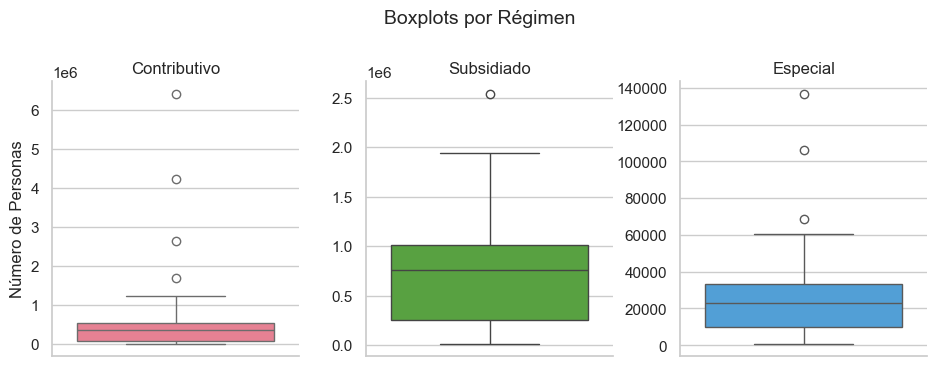

In [23]:
sns.set_theme(style="whitegrid")

# Crear DataFrame combinado
df_box = pd.DataFrame({
    "Contributivo": geo_df_C["NumPersonas"],
    "Subsidiado": geo_df_S["NumPersonas"],
    "Especial": geo_df_E["NumPersonas"]
})

# Pasamos a formato largo para seaborn
df_long = df_box.melt(var_name="Régimen", value_name="NumPersonas")

# Asignamos una paleta con colores distintos
colores = sns.color_palette("husl", len(df_long["Régimen"].unique()))

# Creamos el FacetGrid con colores distintos y sin compartir escala en Y
g = sns.FacetGrid(df_long, col="Régimen", sharey=False, height=4, aspect=0.8)

# Mapear cada boxplot con un color diferente
for i, (regimen, color) in enumerate(zip(df_long["Régimen"].unique(), colores)):
    subset = df_long[df_long["Régimen"] == regimen]
    sns.boxplot(y="NumPersonas", data=subset, color=color, ax=g.axes[0][i])

# Ajustes finales
g.set_titles("{col_name}")
g.set_axis_labels("", "Número de Personas")
g.fig.suptitle("Boxplots por Régimen", fontsize=14)
plt.subplots_adjust(top=0.8)
plt.show()

De los boxplots podemos notar que 

- Contributivo: Tiene valores muy grandes y varios outliers extremos → distribución muy sesgada a la derecha.

- Subsidiado: Aunque también hay valores altos, la distribución es un poco más equilibrada.

- Especial: Mucho más concentrado, con valores relativamente pequeños y algunos outliers.

En este caso no podemos tratar los atipicos ya que estariamos eliminando informacion crucial para nuestro analisis. Aun asi, para evitar que los atipicos hagan dificil de interpretar podemos cambiar los esquemas del mapa. Para esto nuestro esquemas ideales serian: 

| Régimen        | Característica de los datos        | Esquema a considerar          | Justificación                                                                                   |
|----------------|------------------------------------|-------------------------------|--------------------------------------------------------------------------------------------------|
| Contributivo    | Altamente sesgado, valores extremos| `NaturalBreaks`| Separa mejor los valores atípicos y muestra bien las diferencias en los rangos más bajos.        |
| Subsidiado      | Moderadamente sesgado             | `Quantiles`                    | Asegura que cada clase tenga la misma cantidad de departamentos, útil para comparaciones.        |
| Especial        | Datos pequeños y concentrados      | `Equal_interval`               | Fácil de interpretar, útil cuando la variabilidad no es muy grande.                             |


## Mapas coropleticos

c:\Users\Alejandro Moya\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Alejandro Moya\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


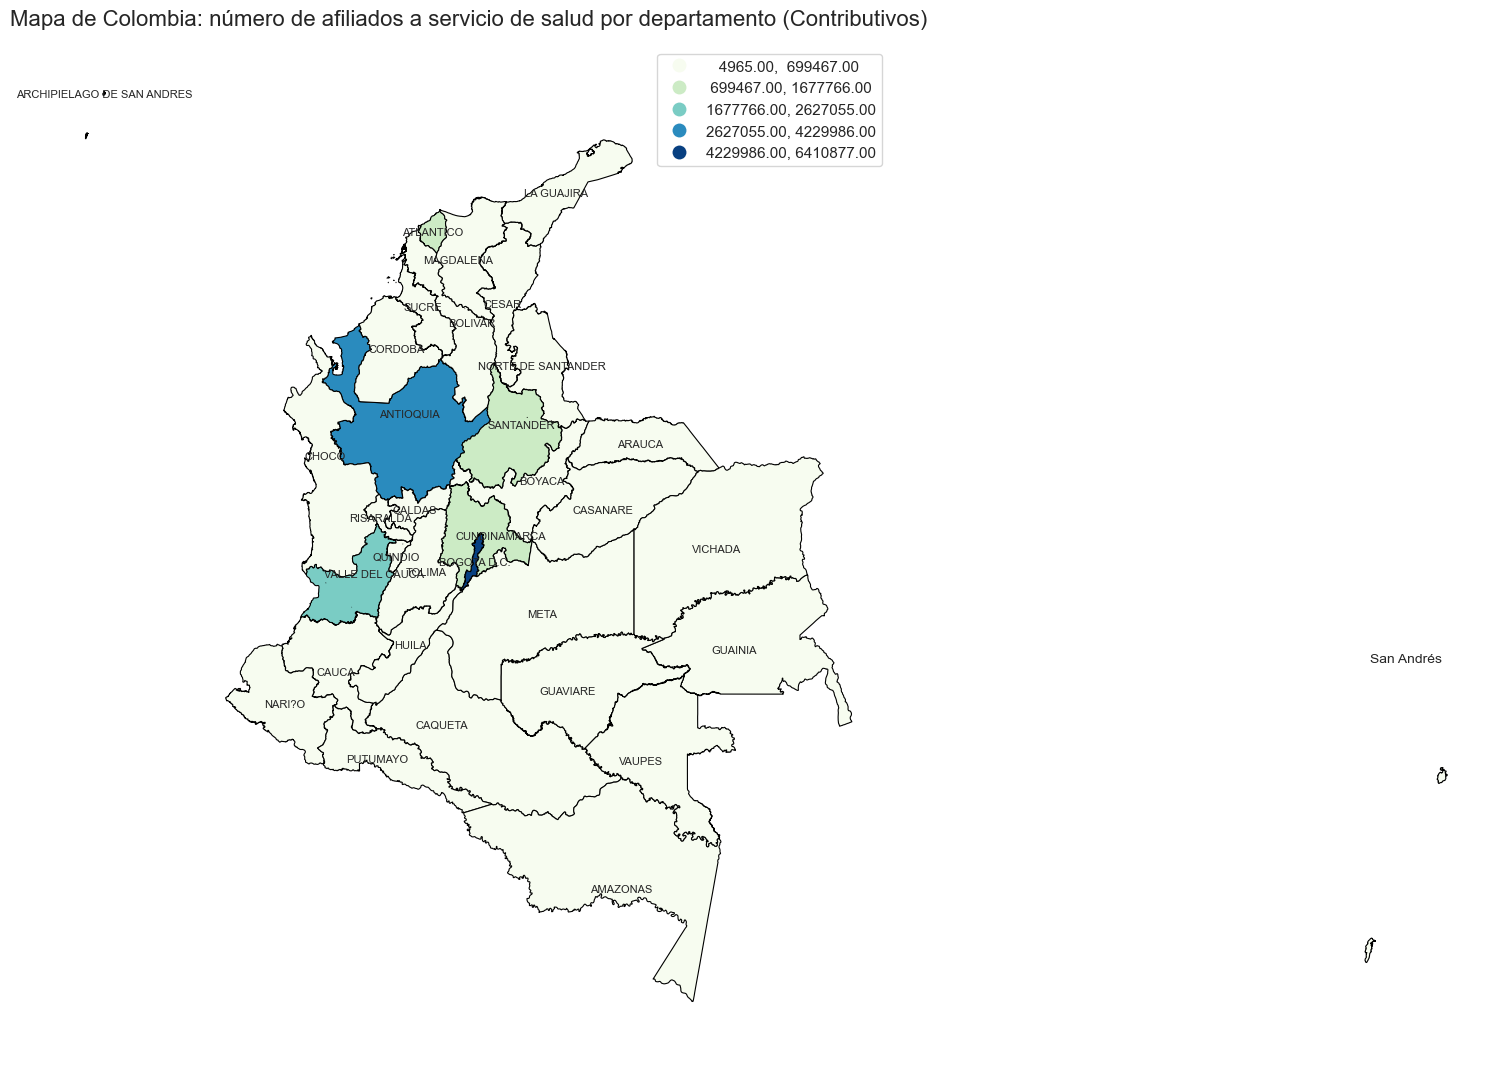

In [25]:
# Crear figura y ejes
fig, ax = plt.subplots(figsize=(30, 13))

# Mapa coroplético
geo_df_C.plot(
    column="NumPersonas",       
    cmap="GnBu",
    scheme="NaturalBreaks",           
    linewidth=0.8,
    ax=ax,
    edgecolor="black",
    legend=True
)

# Agregar etiquetas
for _, row in mapa_col.iterrows():
    x, y = row.geometry.representative_point().coords[0]
    ax.annotate(
        text=row["DPTO_CNMBR"],
        xy=(x, y),
        ha="center",
        va="center",
        fontsize=8
    )

# --- ZOOM A SAN ANDRÉS ---
# Filtrar la geometría de San Andrés
san_andres = geo_df_C[geo_df_C["DPTO_CNMBR"] == "ARCHIPIELAGO DE SAN ANDRES"]

# Obtener límites del bounding box y aplicar un margen
minx, miny, maxx, maxy = san_andres.total_bounds
margin_x = (maxx - minx) * 0.5
margin_y = (maxy - miny) * 0.5

# Crear un eje adicional para el zoom
ax_inset = fig.add_axes([0.75, 0.1, 0.15, 0.3])  # posición del recuadro [left, bottom, width, height]
geo_df_C.plot(
    column="NumPersonas",
    cmap="GnBu",
    scheme= "NaturalBreaks",
    linewidth=0.8,
    ax=ax_inset,
    edgecolor="black",
    legend=False
)
ax_inset.set_xlim(minx - margin_x, maxx + margin_x)
ax_inset.set_ylim(miny - margin_y, maxy + margin_y)
ax_inset.set_title("San Andrés", fontsize=10)
ax_inset.set_axis_off()

# Título principal
ax.set_axis_off()
ax.set_title(
    "Mapa de Colombia: número de afiliados a servicio de salud por departamento (Contributivos)",
    pad=15,
    fontsize=16
)

plt.show()

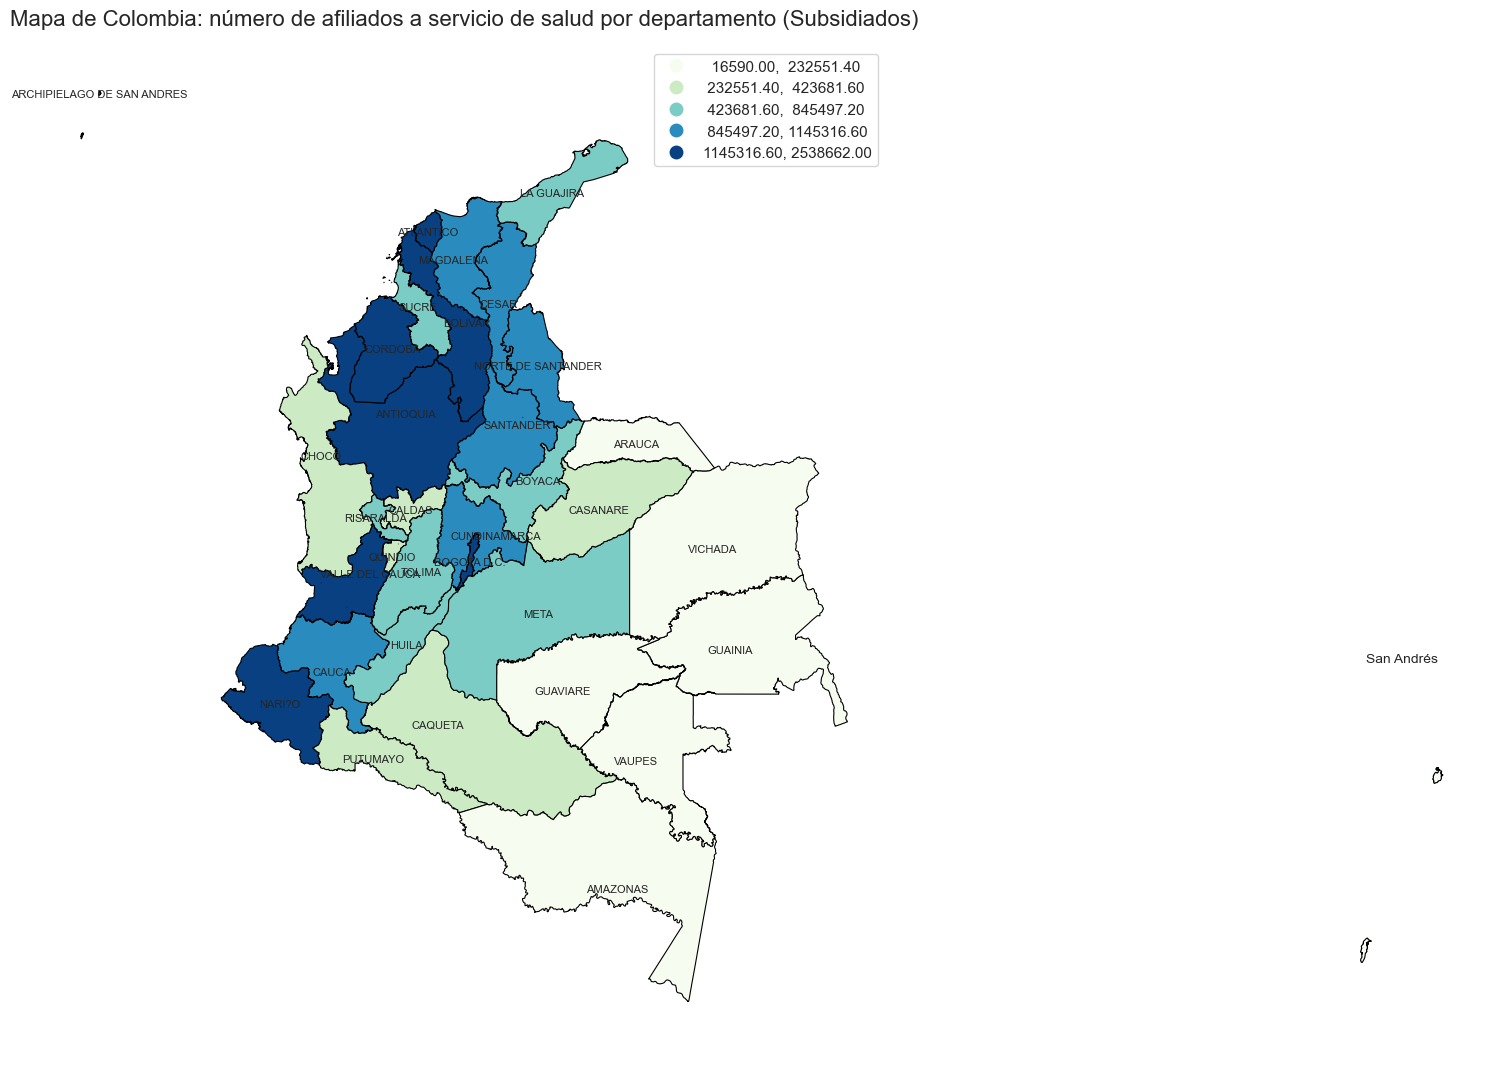

In [26]:
# Crear figura y ejes
fig, ax = plt.subplots(figsize=(30, 13))

# Mapa coroplético
geo_df_S.plot(
    column="NumPersonas",       
    cmap="GnBu", 
    scheme="quantiles",         
    linewidth=0.8,
    ax=ax,
    edgecolor="black",
    legend=True
)

# Agregar etiquetas
for _, row in mapa_col.iterrows():
    x, y = row.geometry.representative_point().coords[0]
    ax.annotate(
        text=row["DPTO_CNMBR"],
        xy=(x, y),
        ha="center",
        va="center",
        fontsize=8
    )

# --- ZOOM A SAN ANDRÉS ---
# Filtrar la geometría de San Andrés
san_andres = geo_df_S[geo_df_S["DPTO_CNMBR"] == "ARCHIPIELAGO DE SAN ANDRES"]

# Obtener límites del bounding box y aplicar un margen
minx, miny, maxx, maxy = san_andres.total_bounds
margin_x = (maxx - minx) * 0.5
margin_y = (maxy - miny) * 0.5

# Crear un eje adicional para el zoom
ax_inset = fig.add_axes([0.75, 0.1, 0.15, 0.3])  # posición del recuadro [left, bottom, width, height]
geo_df_S.plot(
    column="NumPersonas",
    cmap="GnBu",
    scheme="quantiles",
    linewidth=0.8,
    ax=ax_inset,
    edgecolor="black",
    legend=False
)
ax_inset.set_xlim(minx - margin_x, maxx + margin_x)
ax_inset.set_ylim(miny - margin_y, maxy + margin_y)
ax_inset.set_title("San Andrés", fontsize=10)
ax_inset.set_axis_off()

# Título principal
ax.set_axis_off()
ax.set_title(
    "Mapa de Colombia: número de afiliados a servicio de salud por departamento (Subsidiados)",
    pad=15,
    fontsize=16
)

plt.show()

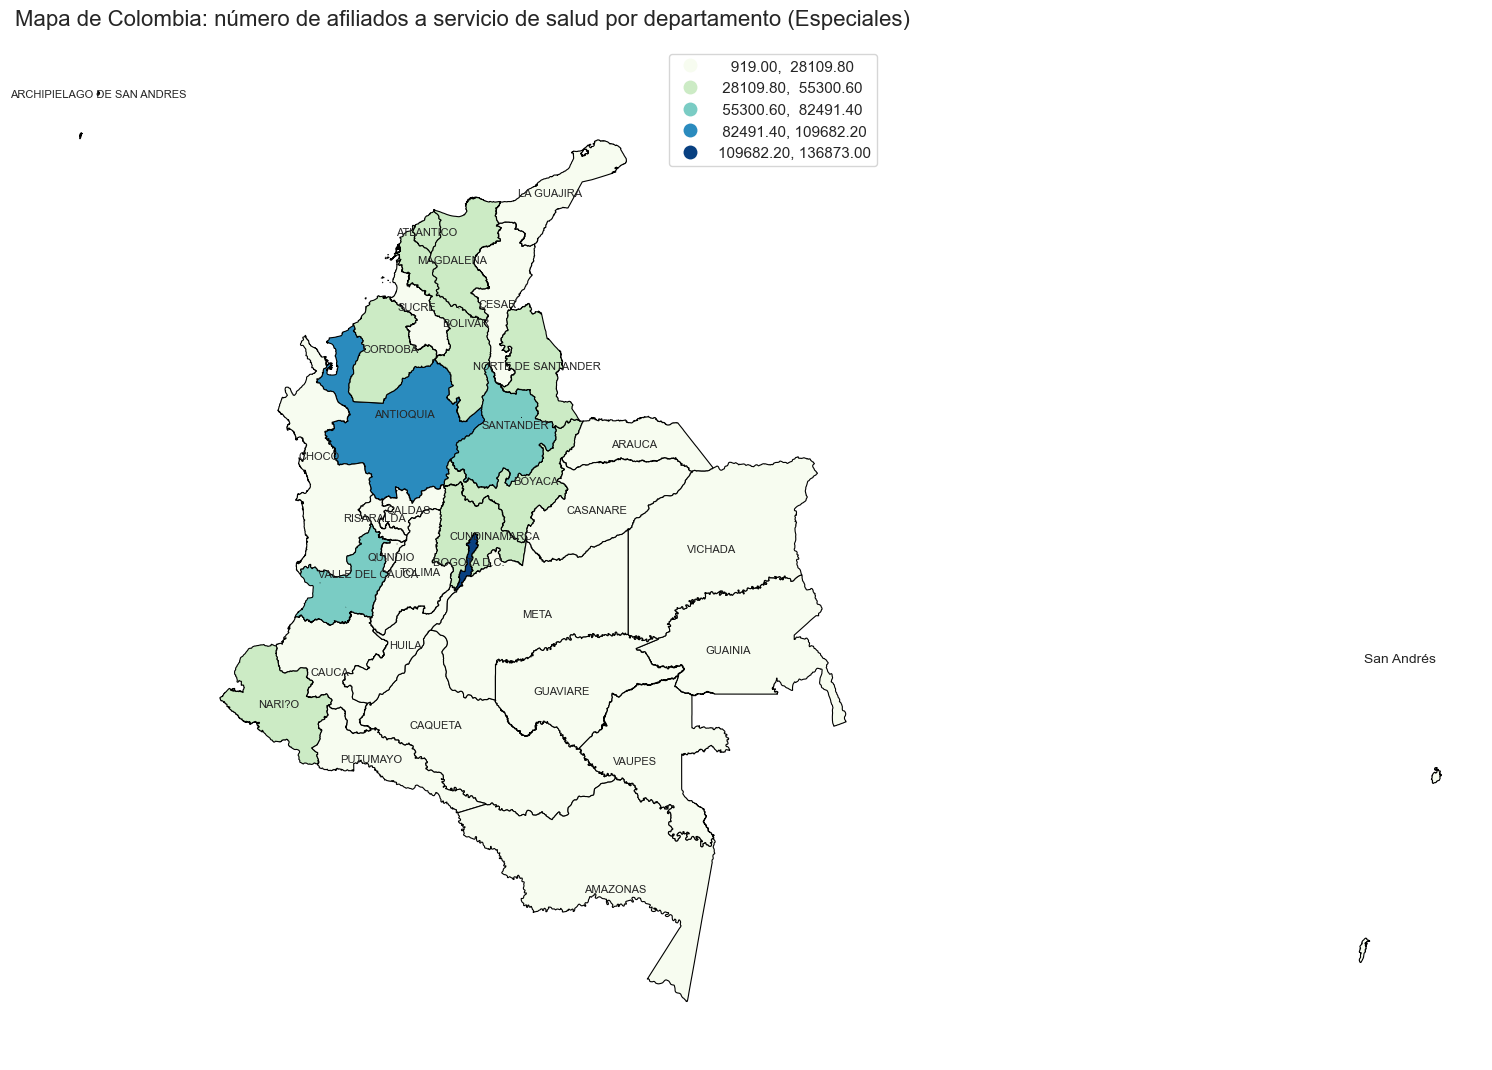

In [27]:
# Crear figura y ejes
fig, ax = plt.subplots(figsize=(30, 13))

# Mapa coroplético
geo_df_E.plot(
    column="NumPersonas",       
    cmap="GnBu", 
    scheme="Equal_interval",          
    linewidth=0.8,
    ax=ax,
    edgecolor="black",
    legend=True
)

# Agregar etiquetas
for _, row in mapa_col.iterrows():
    x, y = row.geometry.representative_point().coords[0]
    ax.annotate(
        text=row["DPTO_CNMBR"],
        xy=(x, y),
        ha="center",
        va="center",
        fontsize=8
    )

# --- ZOOM A SAN ANDRÉS ---
# Filtrar la geometría de San Andrés
san_andres = geo_df_E[geo_df_E["DPTO_CNMBR"] == "ARCHIPIELAGO DE SAN ANDRES"]

# Obtener límites del bounding box y aplicar un margen
minx, miny, maxx, maxy = san_andres.total_bounds
margin_x = (maxx - minx) * 0.5
margin_y = (maxy - miny) * 0.5

# Crear un eje adicional para el zoom
ax_inset = fig.add_axes([0.75, 0.1, 0.15, 0.3])  # posición del recuadro [left, bottom, width, height]
geo_df_E.plot(
    column="NumPersonas",
    cmap="GnBu",
    scheme="Equal_interval",
    linewidth=0.8,
    ax=ax_inset,
    edgecolor="black",
    legend=False
)
ax_inset.set_xlim(minx - margin_x, maxx + margin_x)
ax_inset.set_ylim(miny - margin_y, maxy + margin_y)
ax_inset.set_title("San Andrés", fontsize=10)
ax_inset.set_axis_off()

# Título principal
ax.set_axis_off()
ax.set_title(
    "Mapa de Colombia: número de afiliados a servicio de salud por departamento (Especiales)",
    pad=15,
    fontsize=16
)

plt.show()

## Interpretación de Resultados

Los mapas coropléticos permiten observar la distribución geográfica de los afiliados en cada régimen.  
Algunos hallazgos relevantes:
- **Régimen Contributivo:** Se concentra en departamentos con mayor actividad económica e industrial.
- **Régimen Subsidiado:** Tiende a predominar en regiones con menores niveles de ingreso y mayor dispersión rural.
- **Régimen Especial:** Su cobertura es mucho menor y está asociada a poblaciones específicas.

Estos resultados pueden apoyar la planificación de políticas públicas y la focalización de recursos en salud.